In [4]:
import os
os.getcwd()


'c:\\Users\\vedik\\AppData\\Local\\Programs\\Microsoft VS Code'

In [6]:
import os
os.listdir()

['10c8e557c8',
 '560a9dba96',
 'bin',
 'Code.exe',
 'Code.VisualElementsManifest.xml',
 'new_Code.exe',
 'new_Code.VisualElementsManifest.xml',
 'unins000.dat',
 'unins000.exe',
 'unins000.msg']

In [5]:
df = pd.read_csv(r'C:\Users\vedik\Downloads\project_sales_dataset.csv')
df.head()

,Order ID,Order Date,Ship Date,Customer Name,Segment,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,924c67b8-a55a-4dba-b723-bf96ec09fab4,2024-12-31,2025-06-15,Mrs. Jessica Harmon,Home Office,East,Office Supplies,Labels,Synthesize Clicks-And-Mortar Synergies,276.26,1,0.23,-126.84
1,bc0d0698-1826-456c-bc57-792913784eff,2024-09-27,2025-06-20,Brandy Allen,Consumer,Central,Office Supplies,Binders,Transform Web-Enabled Supply-Chains,19.52,9,0.27,-9.42
2,7825865c-10ed-42a1-92b1-6689794de504,2025-04-27,2025-07-16,Dawn Williams,Corporate,West,Office Supplies,Paper,Whiteboard Robust Channels,916.98,5,0.42,188.17
3,fe691d97-6f6a-4a55-802d-7e45936417c3,2024-05-13,2024-12-03,Brenda Jones,Consumer,East,Office Supplies,Labels,Reinvent Clicks-And-Mortar E-Tailers,955.64,10,0.42,133.20
4,58f38c41-46c7-4311-a61f-615e30d4aedd,2025-01-05,2025-02-14,Heather Washington,Consumer,West,Furniture,Chairs,Facilitate Frictionless E-Commerce,1267.52,5,0.21,149.29


checking null values

In [7]:
df.isnull().sum()

Order ID         0
Order Date       0
Ship Date        0
Customer Name    0
Segment          0
Region           0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

convert date column


In [10]:
df.drop_duplicates(inplace=True)

remove duplicates

EXPLORING THE DATASET

Total Sales

In [11]:
total_sales = df['Sales'].sum()
print(total_sales)

388738.1


Sales by Category

In [12]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Office Supplies    146255.30
Technology         124421.29
Furniture          118061.51
Name: Sales, dtype: float64

Monthly Sales Trend

In [13]:
df['Month'] = df['Order Date'].dt.month
df.groupby('Month')['Sales'].sum()

Month
1     37159.12
2     26532.99
3     33469.04
4     37147.08
5     37053.74
6     33533.69
7     22439.03
8     43242.41
9     23504.14
10    32641.76
11    33816.43
12    28198.67
Name: Sales, dtype: float64

Top cities

In [15]:
df.groupby('Region')['Sales'].sum().sort_values(ascending=False).head(10)

Region
South      105270.02
Central    101145.29
West        95494.66
East        86828.13
Name: Sales, dtype: float64

VISUALIZATION

In [16]:
import matplotlib.pyplot as plt

Monthly Sales

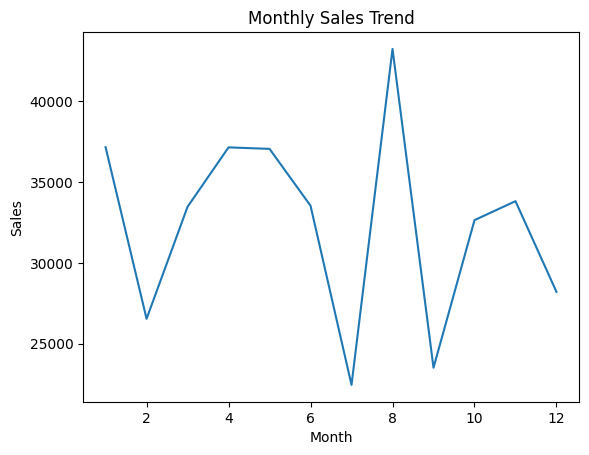

In [17]:
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(kind='line')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

SALES BY REGION

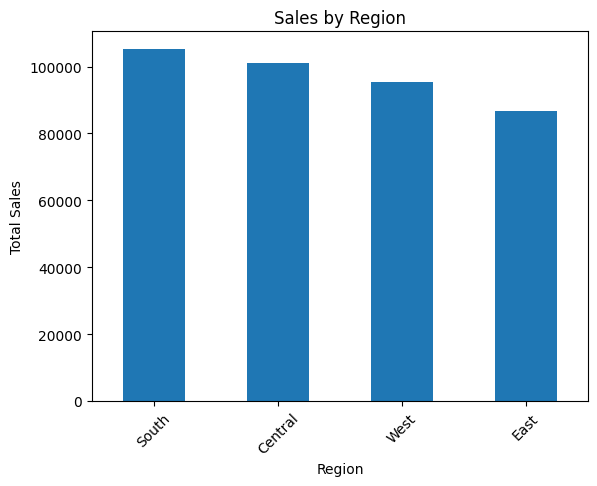

In [25]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

region_sales.plot(kind='bar')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

SALES BY CATEGORY

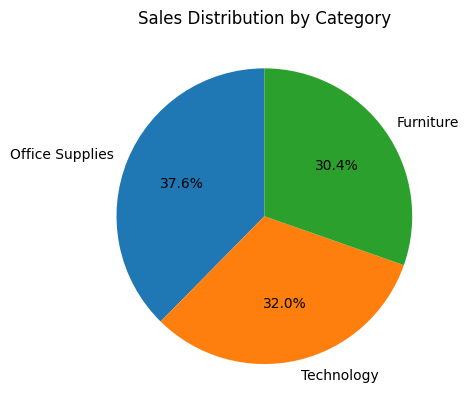

In [28]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

category_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Sales Distribution by Category')
plt.ylabel('')
plt.show()

In [29]:
df.groupby(['Region', 'Category'])['Sales'].sum().unstack()

Category,Furniture,Office Supplies,Technology
Region,,,
Central,25145.46,40351.56,35648.27
East,26254.33,34483.89,26089.91
South,40887.43,34305.78,30076.81
West,25774.29,37114.07,32606.30


In [31]:
import os
os.makedirs('visuals', exist_ok=True)

In [33]:

plt.savefig('visuals/category_sales.png')
plt.savefig('visuals/region_sales.png')
plt.savefig('visuals/monthly_sales.png') 

<Figure size 640x480 with 0 Axes>